# Predicting T-shirt size using the ANSUR II dataset
We will here try to predict a persons t-shirt size given the weight and height of the person. We will use the ANSUR II dataset which contains a lot of information about the physical attributes of a large number of people. 

We will first try to map the persons in the dataset to a t-shirt size. It is hard to find a concise size chart for t-shirt so we will create our own, initial chart, based on these assumptions:

We will only look at two measurements, Shoulder Width and Chest Circumference.

Our first problem is that Shoulder Width is not one of the measurements taken in the dataset. But we have Biacromial Breadth which is the distance between the two acromion processes. We will assume that this is the same as Shoulder Width.

We will then have these initial rules:

| Size | Percentile |
|------|------------|
| XS   | 0-5        |
| S    | 5-25       |
| M    | 25-50      |
| L    | 50-75      |
| XL   | 75-90      |
| XXL  | 90-97      |
| XXXL | 97-100     |

## Inspect the data

In [3]:
import pandas as pd

In [4]:
female = pd.read_csv('./data/female.csv')

male = pd.read_csv('./data/male.csv')


In [5]:
print(f'For women we have (rows, columns) {female.shape}')

print(f'For men we have (rows, columns) {male.shape}')

For women we have (rows, columns) (1986, 108)
For men we have (rows, columns) (4082, 108)


## Checking the percentiles

Let us determine the percentiles of the data

In [6]:
def compute_percentile_ranges(column):
    #Define percentile ranges
    ranges = [(0, 5), (5, 25), (25, 50), (50, 75), (75, 90), (90, 97), (97, 100)]

    percentiles = {(low, high): (column.quantile(low/100), column.quantile(high/100)) for low, high in ranges}

    counts = {}

    for r, (low, high) in percentiles.items():
        counts[r] = ((column >= low) & (column < high)).sum()
    
    return counts


print(compute_percentile_ranges(female['chestcircumference']))
print(compute_percentile_ranges(female['biacromialbreadth']))

print(compute_percentile_ranges(male['chestcircumference']))
print(compute_percentile_ranges(male['biacromialbreadth']))





{(0, 5): np.int64(100), (5, 25): np.int64(396), (25, 50): np.int64(492), (50, 75): np.int64(499), (75, 90): np.int64(299), (90, 97): np.int64(140), (97, 100): np.int64(59)}
{(0, 5): np.int64(93), (5, 25): np.int64(377), (25, 50): np.int64(477), (50, 75): np.int64(541), (75, 90): np.int64(297), (90, 97): np.int64(139), (97, 100): np.int64(61)}
{(0, 5): np.int64(199), (5, 25): np.int64(810), (25, 50): np.int64(1025), (50, 75): np.int64(1012), (75, 90): np.int64(616), (90, 97): np.int64(295), (97, 100): np.int64(124)}
{(0, 5): np.int64(191), (5, 25): np.int64(787), (25, 50): np.int64(989), (50, 75): np.int64(1079), (75, 90): np.int64(610), (90, 97): np.int64(303), (97, 100): np.int64(122)}


## Generate the t-shirt size chart

In [7]:
def comput_size_percentile_measurements(data, chest_column, shoulder_column):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    ranges = [0, 5, 25 , 50, 75, 90, 97]

    # Compute the values for each percentile for chest and shoulder
    chest_percentiles = {p: data[chest_column].quantile(p/100) for p in ranges}
    shoulder_percentiles = {p: data[shoulder_column].quantile(p/100) for p in ranges}

    # Map the t-shirt sizes to the corresponding chest and shoulder measurements
    size_mappings = {}
    for i, size in enumerate(sizes):
        size_mappings[size] = {
            'Chest': int(chest_percentiles[ranges[i]]),
            'Shoulder': int(shoulder_percentiles[ranges[i]])
        }
    
    return size_mappings



print(comput_size_percentile_measurements(female, 'chestcircumference', 'biacromialbreadth'))
print(comput_size_percentile_measurements(male, 'chestcircumference', 'biacromialbreadth'))

{'XS': {'Chest': 695, 'Shoulder': 283}, 'S': {'Chest': 824, 'Shoulder': 335}, 'M': {'Chest': 889, 'Shoulder': 353}, 'L': {'Chest': 940, 'Shoulder': 365}, 'XL': {'Chest': 999, 'Shoulder': 378}, '2XL': {'Chest': 1057, 'Shoulder': 389}, '3XL': {'Chest': 1117, 'Shoulder': 400}}
{'XS': {'Chest': 774, 'Shoulder': 337}, 'S': {'Chest': 922, 'Shoulder': 384}, 'M': {'Chest': 996, 'Shoulder': 403}, 'L': {'Chest': 1056, 'Shoulder': 415}, 'XL': {'Chest': 1117, 'Shoulder': 428}, '2XL': {'Chest': 1172, 'Shoulder': 441}, '3XL': {'Chest': 1233, 'Shoulder': 452}}


In [8]:

female_size = {
    'XS': {'Chest': 695, 'Shoulder': 283}, 
    'S': {'Chest': 824, 'Shoulder': 335}, 
    'M': {'Chest': 889, 'Shoulder': 353}, 
    'L': {'Chest': 940, 'Shoulder': 365}, 
    'XL': {'Chest': 999, 'Shoulder': 378}, 
    '2XL': {'Chest': 1057, 'Shoulder': 389}, 
    '3XL': {'Chest': 1117, 'Shoulder': 400}
    }

male_sizes = {
    'XS': {'Chest': 774, 'Shoulder': 337}, 
    'S': {'Chest': 922, 'Shoulder': 384}, 
    'M': {'Chest': 996, 'Shoulder': 403}, 
    'L': {'Chest': 1056, 'Shoulder': 415}, 
    'XL': {'Chest': 1117, 'Shoulder': 428}, 
    '2XL': {'Chest': 1172, 'Shoulder': 441}, 
    '3XL': {'Chest': 1233, 'Shoulder': 452}
    }

## Lab

In [9]:
def check_match_conflict(data, column_chest, column_breadth, g_size):
  keys = list(g_size.keys()) #list of sizes
  count_match = 0
  count_conflict = 0
  
  for ch, sh in zip(data[column_chest], data[column_breadth]):
    matched = False

    for n in range(len(keys) - 1):
      chest_low_size = g_size[keys[n]]['Chest']
      chest_high_size = g_size[keys[n+1]]['Chest']
      shoulder_low_size = g_size[keys[n]]['Shoulder']
      shoulder_high_size = g_size[keys[n+1]]['Shoulder']
      
      if (ch >= chest_low_size and ch < chest_high_size) and (sh >= shoulder_low_size and sh < shoulder_high_size ):
        count_match += 1
        matched = True
        break

    if not matched:
        if (ch >= g_size['3XL']['Chest'] ) and (sh >= g_size['3XL']['Shoulder']):
          count_match += 1
          matched = True

    if not matched:
        count_conflict += 1
   
  print(f'Total match: {count_match}')
  print(f'Total conflict: {count_conflict}')

check_match_conflict(female, 'chestcircumference', 'biacromialbreadth', female_size)
check_match_conflict(male, 'chestcircumference', 'biacromialbreadth', male_sizes)

Total match: 474
Total conflict: 1512
Total match: 1177
Total conflict: 2905


## Lab Answer 

In [10]:
def get_size(data, size_chart):
  matches = { size: 0 for size in size_chart.keys()}
  ties = 0

  for _, row in data.iterrows():
    possible_sizes = []

    for size, measurments in size_chart.items():
      if (row['biacromialbreadth'] <= measurments['Shoulder'] and
         row['chestcircumference'] <= measurments['Chest'] ):
        possible_sizes.append(size)
    
    if len(possible_sizes)==1:
      matches[possible_sizes[0]]+=1
    elif len(possible_sizes)>1:
      ties+=1
  return matches, ties

In [11]:
female_matches, female_ties = get_size(female, female_size)
male_matches, male_ties = get_size(male, male_sizes)

print('Female matches: ', female_matches)

Female matches:  {'XS': 0, 'S': 0, 'M': 0, 'L': 0, 'XL': 0, '2XL': 0, '3XL': 236}


In [12]:
def create_overlapping_size_chart(orginal_chart):
  overlapping_chart = {}

  sizes = list(orginal_chart.keys())

  for i, size in enumerate(sizes):
    overlapping_chart[size] = {}
    if i == 0:
      overlapping_chart[size]['Chest'] = [orginal_chart[size]['Chest'], orginal_chart[sizes[i+1]]['Chest']+5]
      overlapping_chart[size]['Shoulder'] = [orginal_chart[size]['Shoulder'], orginal_chart[sizes[i+1]]['Shoulder']+5]
    elif i == len(sizes)-1:
      overlapping_chart[size]['Chest'] = [orginal_chart[size]['Chest'] - 5, orginal_chart[size]['Chest']+1000]
      overlapping_chart[size]['Shoulder'] = [orginal_chart[size]['Shoulder'] - 5, orginal_chart[size]['Shoulder']+1000]
    else:
      overlapping_chart[size]['Chest'] = [orginal_chart[size]['Chest']-5, orginal_chart[sizes[i+1]]['Chest']+5]
      overlapping_chart[size]['Shoulder'] = [orginal_chart[size]['Shoulder'] - 5, orginal_chart[sizes[i+1]]['Shoulder']+5]
  
  return overlapping_chart
    

In [13]:
new_female_sizes = create_overlapping_size_chart(female_size)
new_male_sizes = create_overlapping_size_chart(male_sizes)

for k, v in new_female_sizes.items():
 print(f"'{k}' : {v}")

print()
for k, v in new_male_sizes.items():
  print(f"'{k}' : {v}")


'XS' : {'Chest': [695, 829], 'Shoulder': [283, 340]}
'S' : {'Chest': [819, 894], 'Shoulder': [330, 358]}
'M' : {'Chest': [884, 945], 'Shoulder': [348, 370]}
'L' : {'Chest': [935, 1004], 'Shoulder': [360, 383]}
'XL' : {'Chest': [994, 1062], 'Shoulder': [373, 394]}
'2XL' : {'Chest': [1052, 1122], 'Shoulder': [384, 405]}
'3XL' : {'Chest': [1112, 2117], 'Shoulder': [395, 1400]}

'XS' : {'Chest': [774, 927], 'Shoulder': [337, 389]}
'S' : {'Chest': [917, 1001], 'Shoulder': [379, 408]}
'M' : {'Chest': [991, 1061], 'Shoulder': [398, 420]}
'L' : {'Chest': [1051, 1122], 'Shoulder': [410, 433]}
'XL' : {'Chest': [1112, 1177], 'Shoulder': [423, 446]}
'2XL' : {'Chest': [1167, 1238], 'Shoulder': [436, 457]}
'3XL' : {'Chest': [1228, 2233], 'Shoulder': [447, 1452]}


In [14]:
new_female_sizes = {
  'XS' : {'Chest': [695, 829], 'Shoulder': [283, 340]},
  'S' : {'Chest': [819, 894], 'Shoulder': [330, 358]},
  'M' : {'Chest': [884, 945], 'Shoulder': [348, 370]},
  'L' : {'Chest': [935, 1004], 'Shoulder': [360, 383]},
  'XL' : {'Chest': [994, 1062], 'Shoulder': [373, 394]},
  '2XL' : {'Chest': [1052, 1122], 'Shoulder': [384, 405]},
  '3XL' : {'Chest': [1112, 2117], 'Shoulder': [395, 1400]}
}

new_male_sizes = {
 'XS' : {'Chest': [774, 927], 'Shoulder': [337, 389]},
  'S' : {'Chest': [917, 1001], 'Shoulder': [379, 408]},
  'M' : {'Chest': [991, 1061], 'Shoulder': [398, 420]},
  'L' : {'Chest': [1051, 1122], 'Shoulder': [410, 433]},
  'XL' : {'Chest': [1112, 1177], 'Shoulder': [423, 446]},
  '2XL' : {'Chest': [1167, 1238], 'Shoulder': [436, 457]},
  '3XL' : {'Chest': [1228, 2233], 'Shoulder': [447, 1452]},
}



## Lab

In [15]:
def get_size(data, size_chart):
  matches = { size: 0 for size in size_chart.keys()}
  keys = list(size_chart.keys())
  ties = 0

  for _, row in data.iterrows():
    possible_sizes = []

    for size, measurments in size_chart.items():
      if ( (row['chestcircumference'] >= measurments['Chest'][0] 
          and row['chestcircumference'] <= measurments['Chest'][1]) 
          and (row['biacromialbreadth'] >= measurments['Shoulder'][0] 
          and row['biacromialbreadth'] <= measurments['Shoulder'][1] )):
            possible_sizes.append(size)
    
    if len(possible_sizes)==1:
      matches[possible_sizes[0]]+=1
    elif len(possible_sizes) > 1:
      adjancent = True
      for n in range(len(possible_sizes)-1):
        index1 = keys.index(possible_sizes[n])
        index2 = keys.index(possible_sizes[n+1])
        if index2 - index1 != 1:
          adjancent = False
          ties+=1
          break
      if adjancent:
         matches[possible_sizes[len(possible_sizes) - 1]]+=1

  return matches, ties

In [16]:
female_matches, female_ties = get_size(female, new_female_sizes)
male_matches, male_ties = get_size(male, new_male_sizes)

print('Female matches: ', female_matches)
print('Female ties: ', female_ties)
print()
print('Male matches: ', male_matches)
print('Male ties: ', male_ties)

Female matches:  {'XS': 23, 'S': 185, 'M': 247, 'L': 276, 'XL': 118, '2XL': 35, '3XL': 13}
Female ties:  0

Male matches:  {'XS': 63, 'S': 428, 'M': 578, 'L': 593, 'XL': 331, '2XL': 101, '3XL': 50}
Male ties:  0


## Lab Answer

In [17]:
def get_size(data, size_chart):
  matches = { size: 0 for size in size_chart.keys()}
  ties = 0
  size_ordered = list(size_chart.keys())

  for _, row in data.iterrows():
    possible_sizes = []

    for size, measurments in size_chart.items():
      if (row['biacromialbreadth'] >= measurments['Shoulder'][0] and 
          row['biacromialbreadth'] <= measurments['Shoulder'][1] and
          row['chestcircumference'] >= measurments['Chest'][0] and
          row['chestcircumference'] <= measurments['Chest'][1] ):
          possible_sizes.append(size)
      
    if len(possible_sizes) == 1:
      matches[possible_sizes[0]]+=1
    elif len(possible_sizes) > 1:        
      are_adjancent = all([abs(size_ordered.index(possible_sizes[i]) - size_ordered.index(possible_sizes[i+1])) == 1
                              for i in range(len(possible_sizes) -1)])
      if are_adjancent:
          larger_size = max(possible_sizes, key= lambda s: size_ordered.index(s))
          matches[larger_size] += 1
      
      else:
          ties+=1
  
  return matches, ties
  
          

      

In [18]:
female_matches, female_ties = get_size(female, new_female_sizes)
male_matches, male_ties = get_size(male, new_male_sizes)

print('Female matches: ', female_matches)
print('Female ties: ', female_ties)
print()
print('Male matches: ', male_matches)
print('Male ties: ', male_ties)

Female matches:  {'XS': 23, 'S': 185, 'M': 247, 'L': 276, 'XL': 118, '2XL': 35, '3XL': 13}
Female ties:  0

Male matches:  {'XS': 63, 'S': 428, 'M': 578, 'L': 593, 'XL': 331, '2XL': 101, '3XL': 50}
Male ties:  0


In [19]:
result = all([True, True, False])
print(result)

x=10
result= all([x<15, x==10, x>12])
print(result)

False
False


In [20]:
def determine_size(value, measurement, size_dict):
    """
    Determine clothing sizes that match the given body measurement value.
   
    Iterates through the provided size dictionary and finds all sizes where the
    measurement range contains the given value.
   
    Parameters:
      value: The body measurement value
      measurement: The name of the measurement type
      size_dict: Dictionary mapping clothing sizes to measurement ranges
   
    Returns:
      sizes: List of clothing sizes matching the measurement value
    """
    sizes = []
    for size, measurements in size_dict.items():
        if measurements[measurement][0] <= value <= measurements[measurement][1]:
            sizes.append(size)
    return sizes
 
def determine_individual_size(row, size_dict):
    """
    Determine individual clothing size based on chest circumference and shoulder width.
    Matches the chest and shoulder measurements to clothing sizes in the provided size dictionary.
    Returns a single matching size, or the larger of two adjacent sizes if there are multiple matches.
    Returns None if no size matches or adjacent sizes cannot be determined.
    """
    chest_size = determine_size(row['chestcircumference'], 'Chest', size_dict)
    shoulder_size = determine_size(row['biacromialbreadth'], 'Shoulder', size_dict)
   
    matching_sizes = list(set(chest_size) & set(shoulder_size))
   
    if len(matching_sizes) == 1:
        return matching_sizes[0]
    elif len(matching_sizes) > 1:
        # Check if sizes are adjacent, if so, select the larger size
        size_order = list(size_dict.keys())
        adjacent = all([abs(size_order.index(a) - size_order.index(b)) <= 1 for a in matching_sizes for b in matching_sizes])
        if adjacent:
            return max(matching_sizes, key=lambda x: size_order.index(x))
    return None


In [21]:
female['t-shirt size'] = female.apply(determine_individual_size, args=(new_female_sizes,), axis=1)
male['t-shirt size'] = male.apply(determine_individual_size, args=(new_male_sizes,), axis=1)

In [22]:
female['t-shirt size'].value_counts()

t-shirt size
L      276
M      247
S      185
XL     118
2XL     35
XS      23
3XL     13
Name: count, dtype: int64

In [23]:
female_filtered = female.dropna(subset=['t-shirt size'])
male_filtered = male.dropna(subset=['t-shirt size'])


In [24]:
female_filtered.shape

(897, 109)

In [25]:
male_filtered.shape

(2144, 109)

In [26]:
columns = ['chestcircumference', 'biacromialbreadth', 'weightkg', 'stature', 't-shirt size']
female_dataset = female_filtered[columns]
male_dataset = male_filtered[columns]


In [27]:
female_dataset.to_csv('./data/female_sized.csv', index=False)
female_dataset.to_csv('./data/male_sized.csv', index=False)

## Why Create a Scatter Plot

Visualize the distribution of t-shirt sizes

identify Patterns or Trends

Compare men and women (data)

communicate results

identity potential outliers


C:\Users\furti\AppData\Local\Temp\ipykernel_10000\1094542378.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[166.  167.1 152.1 166.8 165.4 159.9 167.3 167.8 162.3 166.8 164.4 144.6
 168.4 161.9 159.2 172.3 163.4 168.3 155.2 164.1 168.5 165.6 160.8 166.4
 158.2 172.  153.6 154.6 160.5 163.2 166.1 166.5 155.5 157.8 158.1 169.8
 165.1 165.7 164.9 168.7 169.8 153.  160.9 160.6 174.5 160.7 156.  167.
 150.1 157.6 157.6 162.6 160.4 153.8 162.  173.3 173.2 162.4 150.7 164.
 152.6 167.1 165.5 163.5 166.2 170.1 160.2 154.9 167.7 159.4 162.8 161.9
 169.  170.5 162.5 159.5 164.3 166.7 166.1 156.  161.  160.4 154.  163.8
 174.9 166.1 158.3 153.3 177.6 171.3 168.7 160.3 161.7 169.  162.3 157.
 161.6 169.  158.8 152.  163.1 164.2 177.3 162.3 163.  151.2 167.5 149.8
 153.8 156.7 159.  159.5 156.5 152.3 155.6 159.9 161.1 167.4 159.2 161.7
 159.7 160.9 169.6 172.3 169.5 158.7 171.2 162.8 152.  161.6 164.9 165.3
 163.8 164.6 1

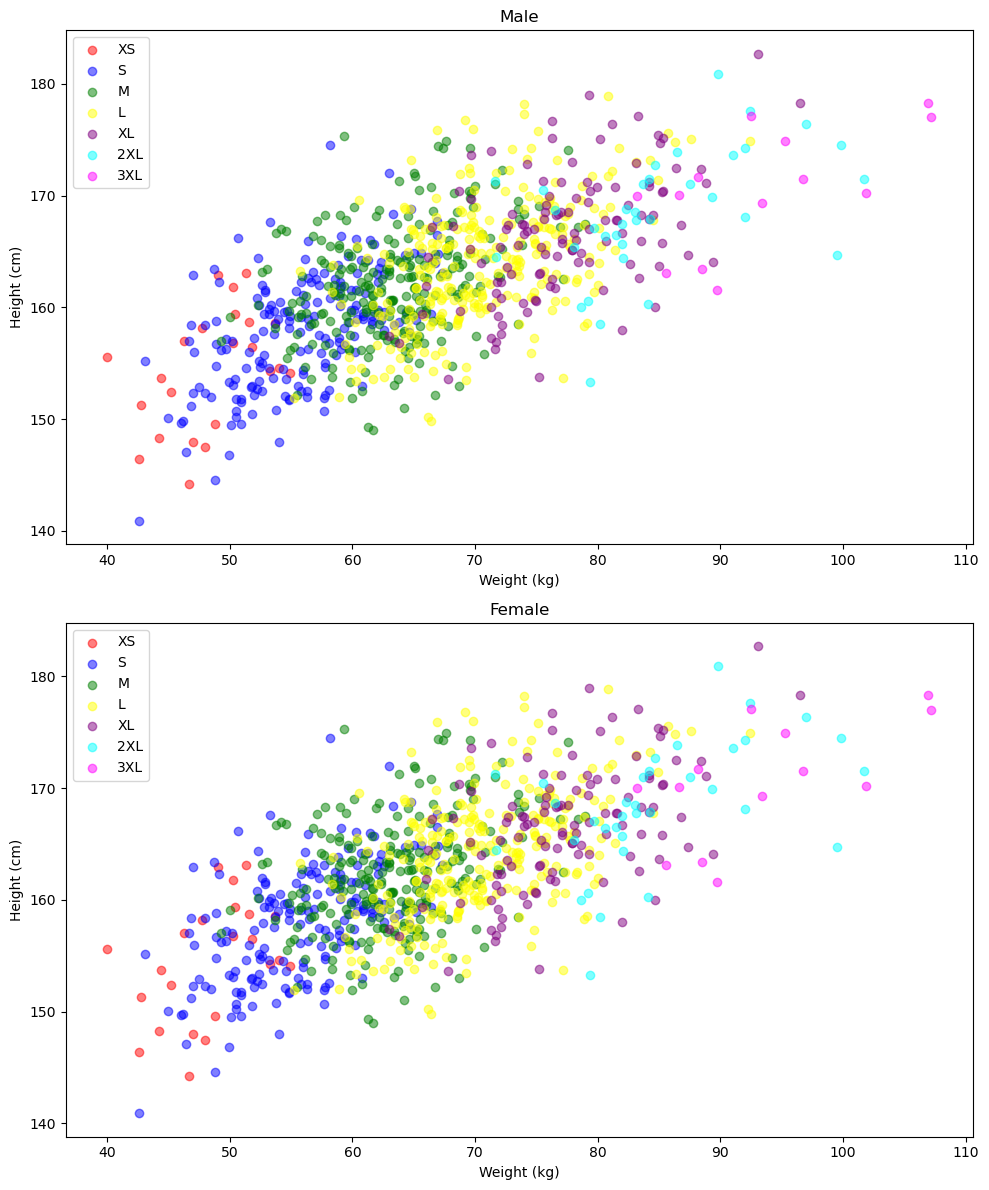

In [28]:
import matplotlib.pyplot as plt

# First let us define a dict to match a t-shirt size to a color
colors = {
    'XS': 'red',
    'S': 'blue',
    'M': 'green',
    'L': 'yellow',
    'XL': 'purple',
    '2XL': 'cyan',
    '3XL': 'magenta'
}
 
male_dataset = pd.read_csv('./data/male_sized.csv')
female_dataset = pd.read_csv('./data/female_sized.csv')
# For male_dataset
male_dataset.loc[:, 'stature'] = male_dataset['stature'] / 10
male_dataset.loc[:, 'weightkg'] = male_dataset['weightkg'] / 10
 
# For female_dataset
female_dataset.loc[:, 'stature'] = female_dataset['stature'] / 10
female_dataset.loc[:, 'weightkg'] = female_dataset['weightkg'] / 10
 
# Create plots for each gender
fig, axes = plt.subplots(nrows=2, figsize=(10, 12))
 
for ax, gender_data, gender in zip(axes, [male_dataset, female_dataset], ["Male", "Female"]):
    for size, color in colors.items():
        # Filter data by size
        size_data = gender_data[gender_data["t-shirt size"] == size]
 
        # Plot data
        ax.scatter(size_data["weightkg"], size_data["stature"], c=color, label=size, alpha=0.5)
 
    ax.set_title(gender)
    ax.set_xlabel("Weight (kg)")
    ax.set_ylabel("Height (cm)")
    ax.legend()
 
plt.tight_layout()
plt.show()

In [29]:
import numpy as np

class KNNClassifier:
    def __init__(self, k=5):
        # 1. Constructor for KNNClassifier. Initializes class variables.
        self.k = k
        self.X = None
        self.y = None

    def _calculate_distance(self, x1, x2):
        """
        Calculate the Euclidean distance between two data points, x1 and x2
        """
        # 2. Calculate the Euclidean distance between two data points x1 and x2.
        return ((x1 - x2)**2).sum() ** 0.5

    def _knn_predict(self, x):
        # 3. Predict the class for a given data point x using KNN.
        return sorted([
            (self._calculate_distance(x, measurment), self.y[i])
            for i, measurment in enumerate(self.X)
        ])[:self.k]

    def fit(self, X, y):
        # 4. Train the KNN model with the given training data and labels.
        self.X = np.array(X)
        self.y = np.array(y)

    def _predict(self, neighbors):
        # 5. Determine the final prediction based on the majority class of nearest neighbors.
        labels = [n[1] for n in neighbors]
        label, count = np.unique(labels, return_counts=True)
        max_count = np.max(count)
        
        if np.sum(count == max_count) > 1:
            tied_labels = label[count == max_count]
            # 5a. In case of a tie, select the smallest class based on the order in labels.
            return min(tied_labels, key=labels.index)

        # 5b. Otherwise, select the class with the most votes.
        return label[np.argmax(count)]

    def predict(self, X):
        # 6. Make predictions for a given list of data points X.
        predictions = []
        for x in X:
            neighbors = self._knn_predict(x)
            prediction = self._predict(neighbors)
            # 6a. Add the prediction to the result list.
            predictions.append(prediction)
            
        return predictions


In [30]:
females_X = [(person['stature'], person['weightkg']) for _, person in female_dataset.iterrows()]
females_y = female_dataset['t-shirt size'].values.tolist()

In [31]:
females_X

[(166.0, 78.2),
 (167.1, 76.0),
 (152.1, 54.5),
 (166.8, 74.2),
 (165.4, 78.1),
 (159.9, 70.9),
 (167.3, 67.2),
 (167.8, 59.5),
 (162.3, 49.1),
 (166.8, 70.3),
 (164.4, 71.5),
 (144.6, 48.8),
 (168.4, 73.0),
 (161.9, 61.0),
 (159.2, 65.8),
 (172.3, 72.8),
 (163.4, 62.7),
 (168.3, 57.8),
 (155.2, 52.4),
 (164.1, 89.4),
 (168.5, 68.9),
 (165.6, 75.8),
 (160.8, 74.8),
 (166.4, 80.6),
 (158.2, 47.7),
 (172.0, 69.6),
 (153.6, 67.8),
 (154.6, 60.7),
 (160.5, 68.9),
 (163.2, 61.7),
 (166.1, 69.5),
 (166.5, 81.5),
 (155.5, 64.5),
 (157.8, 55.7),
 (158.1, 61.4),
 (169.8, 66.8),
 (165.1, 75.7),
 (165.7, 68.2),
 (164.9, 78.6),
 (168.7, 62.2),
 (169.8, 78.2),
 (153.0, 60.8),
 (160.9, 68.6),
 (160.6, 77.3),
 (174.5, 99.8),
 (160.7, 68.3),
 (156.0, 47.1),
 (167.0, 68.5),
 (150.1, 45.0),
 (157.6, 72.1),
 (157.6, 53.6),
 (162.6, 63.9),
 (160.4, 62.8),
 (153.8, 75.2),
 (162.0, 61.3),
 (173.3, 74.2),
 (173.2, 76.7),
 (162.4, 66.1),
 (150.7, 50.5),
 (164.0, 66.6),
 (152.6, 58.1),
 (167.1, 79.7),
 (165.5,

In [32]:
females_y

['XL',
 'L',
 'S',
 'XL',
 '2XL',
 'L',
 'L',
 'M',
 'S',
 'L',
 'L',
 'S',
 'XL',
 'M',
 'L',
 'L',
 'M',
 'M',
 'S',
 'XL',
 'L',
 'L',
 'L',
 '2XL',
 'XS',
 'L',
 'XL',
 'L',
 'L',
 'M',
 'L',
 '2XL',
 'M',
 'S',
 'M',
 'L',
 'L',
 'L',
 'XL',
 'M',
 'XL',
 'S',
 'M',
 'L',
 '2XL',
 'L',
 'S',
 'L',
 'S',
 'XL',
 'S',
 'M',
 'L',
 'XL',
 'M',
 'L',
 'L',
 'L',
 'S',
 'L',
 'S',
 '2XL',
 'L',
 'S',
 'S',
 '3XL',
 'M',
 'L',
 'M',
 'M',
 'M',
 'M',
 'L',
 'M',
 'S',
 'L',
 'M',
 'M',
 'XL',
 'S',
 'M',
 'XL',
 'S',
 'M',
 '3XL',
 'L',
 'M',
 'S',
 '2XL',
 '2XL',
 'L',
 'L',
 'L',
 'L',
 'S',
 'S',
 'S',
 'L',
 'S',
 'S',
 'XL',
 'M',
 'L',
 'XL',
 'M',
 'S',
 '2XL',
 'L',
 'L',
 'L',
 'S',
 'L',
 'L',
 'S',
 'L',
 'L',
 'L',
 'L',
 'L',
 'L',
 'XL',
 'L',
 'L',
 'M',
 'L',
 'L',
 'L',
 'M',
 'L',
 'S',
 'M',
 'L',
 'M',
 'S',
 'S',
 'S',
 'M',
 '2XL',
 'M',
 'L',
 'L',
 '2XL',
 '2XL',
 'XL',
 'XL',
 'M',
 'L',
 'L',
 'L',
 'S',
 'L',
 'M',
 'L',
 'XS',
 'XL',
 'M',
 'S',
 'L',
 'L',
 

In [33]:
model = KNNClassifier()
person = [(154, 51)]
model.fit(females_X, females_y)
prediction = model.predict(person)
prediction

[np.str_('S')]

## Test Scikit-Learn

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split # one part for training, second part for testing

male_X = male_dataset.drop(columns=['chestcircumference', 'biacromialbreadth', 't-shirt size'])
male_y = male_dataset['t-shirt size']
female_X = female_dataset.drop(columns=['chestcircumference', 'biacromialbreadth', 't-shirt size'])
female_y = female_dataset['t-shirt size']

male_X_train, male_X_test, male_y_train, male_y_test = train_test_split(male_X, male_y, test_size=0.2, random_state=42)

sk_clf = KNeighborsClassifier()
sk_clf.fit(male_X_train, male_y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Result before any modification

In [35]:
predictions = sk_clf.predict(male_X_test)
predictions

array(['L', 'M', 'S', 'L', 'L', 'M', 'M', 'L', 'XL', 'M', 'XL', 'L', 'L',
       'L', 'L', 'L', 'M', 'XL', 'M', 'S', 'S', 'M', 'XL', 'M', 'L', 'L',
       'L', 'M', 'S', 'M', 'L', '2XL', 'L', 'L', 'M', 'L', 'L', 'XL', 'S',
       'L', 'L', 'S', 'L', 'S', 'S', 'L', 'L', 'L', 'L', 'L', 'M', 'L',
       'S', 'M', 'L', 'S', 'M', 'M', '2XL', '2XL', 'XL', 'S', 'M', 'XL',
       'M', 'L', 'XL', 'M', 'L', 'XL', 'M', 'L', 'S', 'S', 'L', 'M', 'L',
       'M', 'S', 'S', 'M', 'S', 'M', 'M', 'L', 'M', 'L', 'S', 'L', 'M',
       'M', 'L', 'L', 'L', 'L', '2XL', 'M', 'L', 'S', '2XL', '2XL', 'L',
       'S', 'L', 'L', 'L', 'L', 'L', 'L', 'S', 'L', '2XL', 'M', 'S', 'L',
       'XL', 'M', 'L', 'M', 'M', 'S', 'L', 'L', 'L', 'S', 'M', 'M', 'XL',
       'M', 'L', 'L', 'XL', 'XL', 'M', 'S', 'L', 'M', 'S', 'S', 'XL', 'L',
       'L', 'XL', 'M', 'L', 'M', 'S', 'S', 'L', 'S', 'L', 'L', 'M', 'L',
       'M', 'L', 'L', 'M', 'L', 'L', 'S', 'S', 'S', 'L', 'L', 'M', 'L',
       'S', 'S', 'M', 'L', 'M', 'L', 'S', 'XL

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(male_y_test, predictions)

accuracy

0.45

## Lab

## Experiment 1: Check outliers

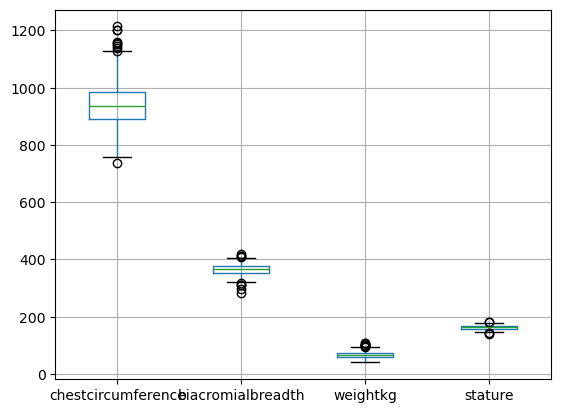

In [69]:
import matplotlib.pyplot as plt
male_dataset.boxplot()
plt.show()

## Remove outliers

In [45]:
from scipy import stats
import numpy as np

male_X = male_dataset.drop(columns=['chestcircumference', 'biacromialbreadth', 't-shirt size'])
male_y = male_dataset['t-shirt size']
female_X = female_dataset.drop(columns=['chestcircumference', 'biacromialbreadth', 't-shirt size'])
female_y = female_dataset['t-shirt size']

f = np.abs(stats.zscore(female_X))
m = np.abs(stats.zscore(male_X))
mask_f = (f < 3).all(axis=1)
mask_m = (m < 3).all(axis=1)

female_X_clean = female_X[mask_f]
female_y_clean = female_y[mask_f]
male_X_clean = male_X[mask_m]
male_y_clean = male_y[mask_m]



## Preprocessing: Add feature scaling

In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split # one part for training, second part for testing
from sklearn.preprocessing import StandardScaler


male_X_train, male_X_test, male_y_train, male_y_test = train_test_split(male_X_clean, male_y_clean, test_size=0.2, random_state=42)

sc = StandardScaler()
male_X_train = sc.fit_transform(male_X_train)
male_X_test =sc.transform(male_X_test)

sk_clf = KNeighborsClassifier(n_neighbors=5)
sk_clf.fit(male_X_train, male_y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [72]:
predictions = sk_clf.predict(male_X_test)
predictions

array(['L', 'L', 'M', 'L', 'S', 'M', 'L', 'L', 'XL', 'M', 'L', '2XL',
       'XL', 'M', 'S', 'S', 'S', 'L', 'M', 'L', 'S', 'L', 'XL', 'L', 'L',
       'L', 'L', 'L', 'L', 'XL', '2XL', 'S', 'S', 'M', 'M', 'XL', 'M',
       'S', 'M', 'L', 'XL', 'S', 'S', 'L', 'M', 'L', 'L', 'XL', 'L', 'M',
       'M', 'L', 'XL', '2XL', 'M', 'L', 'L', 'L', 'S', 'S', 'M', 'M', 'L',
       'XL', 'L', 'M', 'M', 'L', 'S', 'L', 'M', 'XL', 'M', 'L', 'M', 'S',
       'L', 'M', 'L', 'XL', 'L', 'L', 'L', 'M', 'M', 'XL', 'M', 'M', 'L',
       'M', 'S', 'L', 'S', 'S', 'M', 'L', 'S', 'L', 'S', 'L', 'S', 'M',
       'S', 'L', 'L', 'XL', 'M', 'XL', 'L', 'L', 'XL', 'L', 'M', 'L', 'L',
       'S', 'M', 'L', 'L', 'L', 'L', 'XL', 'L', 'M', 'S', 'M', 'M', 'XL',
       'L', 'L', 'S', 'M', 'L', 'M', 'L', 'L', 'S', 'L', 'S', 'XL', 'L',
       'XL', 'L', 'L', 'M', 'L', 'S', '2XL', 'L', 'L', 'S', 'M', 'S', 'L',
       'M', 'L', 'M', 'S', 'XL', 'XL', 'L', 'S', 'L', 'L', 'L', 'S', 'S',
       'M', 'L', 'S', 'L', 'L', 'S', 'S', 'M'

In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(male_y_test, predictions)

accuracy

0.5112359550561798

## Observation:

I used boxplots to spot outliers in the data and then used the Z-score method to remove those extreme values. Since KNN depends on distance, these outliers were affecting the results. I also applied scaling so all features were on the same scale. After removing outliers and scaling the data, the accuracy improved from 0.45 to 0.51.

## Experiment 2: Adjusting the number of neighbors (n_neighbors)

In [53]:
neighbors = []
accuracies = []

for k in range(1,21):
  sk_clf = KNeighborsClassifier(k)
  sk_clf.fit(male_X_train, male_y_train)

  predictions = sk_clf.predict(male_X_test)
  accuracy = accuracy_score(male_y_test, predictions)

  neighbors.append(k)
  accuracies.append(accuracy)

result = pd.DataFrame({
  'n_neighbors': neighbors,
  'accuracy': accuracies
})

In [54]:
print(result)

    n_neighbors  accuracy
0             1  0.460674
1             2  0.455056
2             3  0.455056
3             4  0.516854
4             5  0.511236
5             6  0.505618
6             7  0.511236
7             8  0.500000
8             9  0.466292
9            10  0.483146
10           11  0.477528
11           12  0.500000
12           13  0.516854
13           14  0.516854
14           15  0.488764
15           16  0.511236
16           17  0.500000
17           18  0.511236
18           19  0.494382
19           20  0.505618


## Observation

I tested different values of n_neighbors from 1 to 20 while keeping the data cleaned and scaled. I noticed that very small values of k (1–3) gave lower accuracy. The best results were achieved around k = 4 and k = 13–14 with an accuracy of about 0.5168. When k became too large, the accuracy started to decrease again. This shows how the choice of neighbors affects.

## Experiment with train_test_split

In [ ]:
test_sizes =  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
accuracies = []


for size in test_sizes:
  male_X_train, male_X_test, male_y_train, male_y_test = train_test_split(
    male_X_clean, male_y_clean, test_size=size, random_state=42
  )

  sc = StandardScaler()
  male_X_train = sc.fit_transform(male_X_train)
  male_X_test = sc.transform(male_X_test)

  sk_clf = KNeighborsClassifier(n_neighbors=4)
  sk_clf.fit(male_X_train, male_y_train)

  predictions = sk_clf.predict(male_X_test)
  accuracy = accuracy_score(male_y_test, predictions)

  accuracies.append(accuracy)

split_result = pd.DataFrame({
    'test_size': test_sizes,
    'accuracy': accuracies
})
  

In [74]:
print(split_result)

   test_size  accuracy
0        0.1  0.471910
1        0.2  0.516854
2        0.3  0.490637
3        0.4  0.474719
4        0.5  0.462921
5        0.6  0.460674
6        0.7  0.447833


## Observation
I tested different values of test_size while keeping the data cleaned, scaled, and using the best value of n_neighbors (k=4). I noticed that the highest accuracy was achieved when test_size was 0.2. As the test size increased, the accuracy gradually decreased.

## Experiment: Evaluating with cross_val_score

In [67]:
from sklearn.model_selection import cross_val_score

sc = StandardScaler()
male_X_scaled = sc.fit_transform(male_X_clean)

sk_clf = KNeighborsClassifier(n_neighbors=4)

scores = cross_val_score(sk_clf, male_X_scaled, male_y_clean, cv=5)


print(scores)

[0.53370787 0.46629213 0.54494382 0.47191011 0.44632768]


## Observation

When I evaluated the model using cross-validation, I noticed that the accuracy varied. Some gave high accuracy while others were lower. The average accuracy was around 0.49, which is lower than the single split result. 